# Investment Opportunities in the Global Space Economy

This notebook combines financial metrics with industry positioning to identify the companies that are most likely to benefit from the long-term expansion of the global space economy.

Instead of simply selecting the largest companies, this analysis evaluates each company from multiple dimensions including:

- Industry position
- Revenue scale
- Profitability
- Valuation
- Risk
- Exposure to the space economy

The goal is to identify companies that could become long-term winners as the space economy continues to grow.

In [15]:
import sqlite3
import pandas as pd

conn = sqlite3.connect("../data/space_economy.db")

companies = pd.read_sql("""
SELECT *
FROM companies
""", conn)

financials = pd.read_sql("""
SELECT *
FROM financials
""", conn)

df = companies.merge(financials,on="Ticker")

## 1. Space Economy Exposure Score

Financial performance alone does not indicate whether a company is likely to benefit from the long-term growth of the space economy.

Many large technology companies generate excellent financial results from businesses that are only partially related to space.

To better capture each company's strategic importance within the global space economy, a Space Exposure Score is assigned according to its position in the space industry value chain.

The score ranges from **1 (minimal exposure)** to **5 (pure space company)**.

To combine this metric with other financial indicators, the score is converted to a **0–1 scale** by dividing by 5.

In [22]:
subsector_exposure = {

    "Launch": 5,
    "Satellite Manufacturing": 5,
    "Satellite Communications": 5,
    "Earth Observation": 5,
    "In-space Infrastructure": 5,

    "Ground Infrastructure": 4,
    "Navigation & Positioning": 4,
    "Geospatial Analytics": 4,
    "Aerospace Components": 4,
    "Space Defense": 4,

    "Advanced Materials": 3,
    "Semiconductors": 3,
    "AI & Data Platforms": 3,

    "Cloud Computing": 2

}

In [34]:
# Assign exposure score (1-5)

df["Space Economy Exposure"] = (
    df["Subsector"]
    .map(subsector_exposure)
)

# Normalize to 0-1

df["Space Economy Exposure Score"] = (
    df["Space Economy Exposure"] / 5
)

# Display

df[
    [
        "Company",
        "Subsector",
        "Space Economy Exposure",
        "Space Economy Exposure Score"
    ]
].sort_values(
    by=[
        "Space Economy Exposure",
        "Company"
    ],
    ascending=[False, True]
)

,Company,Subsector,Space Economy Exposure,Space Economy Exposure Score
18,AST SpaceMobile,Satellite Communications,5,1.0
3,Airbus Defence and Space,Satellite Manufacturing,5,1.0
20,BlackSky,Earth Observation,5,1.0
15,EchoStar,Satellite Communications,5,1.0
14,Eutelsat,Satellite Communications,5,1.0
16,Globalstar,Satellite Communications,5,1.0
11,Iridium Communications,Satellite Communications,5,1.0
2,MDA Space,Satellite Manufacturing,5,1.0
19,Planet Labs,Earth Observation,5,1.0
9,Redwire,In-space Infrastructure,5,1.0


## 2. Revenue Growth Score

Revenue growth measures how quickly a company's business is expanding.

Because revenue growth can contain extreme values, directly applying Min-Max normalization may allow a single outlier to dominate the score.

To reduce the influence of extreme observations, revenue growth is winsorised at the 5th and 95th percentiles before being normalized to a 0–1 scale.

In [55]:
# Winsorised Revenue Growth Score (0–1)

growth_lower = df["Revenue Growth"].quantile(0.05)
growth_upper = df["Revenue Growth"].quantile(0.95)

df["Revenue Growth Adjusted"] = (
    df["Revenue Growth"]
    .clip(lower=growth_lower, upper=growth_upper)
)

df["Growth Score"] = (
    df["Revenue Growth Adjusted"] - df["Revenue Growth Adjusted"].min()
) / (
    df["Revenue Growth Adjusted"].max()
    - df["Revenue Growth Adjusted"].min()
)

df[
    [
        "Company",
        "Revenue Growth",
        "Revenue Growth Adjusted",
        "Growth Score"
    ]
].sort_values(
    by="Growth Score",
    ascending=False
).head(15)

,Company,Revenue Growth,Revenue Growth Adjusted,Growth Score
51,L3Harris Technologies,1.900,0.8485,1.000000
18,AST SpaceMobile,19.522,0.8485,1.000000
27,NVIDIA,0.852,0.8485,1.000000
36,Palantir,0.847,0.8470,0.998704
22,Satellogic,0.803,0.8030,0.960691
13,SES,0.664,0.6640,0.840605
1,Rocket Lab,0.635,0.6350,0.815551
9,Redwire,0.579,0.5790,0.767171
29,Broadcom,0.479,0.4790,0.680778
19,Planet Labs,0.421,0.4210,0.630670


## 3. Profitability Score

Profitability measures how efficiently a company converts revenue into earnings.

Companies with stronger profit margins are generally more financially resilient and better positioned to fund future expansion without relying heavily on external financing.

Profit margin is normalized to a 0–1 scale for comparison with the other investment factors.

In [37]:
# Profitability Score (0-1)

df["Profitability Score"] = (
    (df["Profit Margin"] - df["Profit Margin"].min())
    /
    (df["Profit Margin"].max() - df["Profit Margin"].min())
)

df[
    [
        "Company",
        "Profit Margin",
        "Profitability Score"
    ]
].sort_values(
    by="Profitability Score",
    ascending=False
).head(15)

,Company,Profit Margin,Profitability Score
21,Spire Global,0.77116,1.000000
27,NVIDIA,0.62966,0.946616
36,Palantir,0.43673,0.873830
33,Microsoft,0.39342,0.857490
29,Broadcom,0.38848,0.855626
34,Alphabet,0.37919,0.852121
24,Hexagon,0.37516,0.850601
30,Marvell Technology,0.28986,0.818420
35,Oracle,0.25368,0.804770
8,Kongsberg Defence & Aerospace,0.21993,0.792037


## 4. Valuation Score

The Price-to-Sales ratio is used to compare company valuation because many emerging space companies are not yet profitable.

Price-to-Sales values can contain extreme outliers, which may distort Min-Max normalization.

To reduce this effect, the ratio is winsorised at the 5th and 95th percentiles. An inverse transformation is then applied so that companies with lower Price-to-Sales ratios receive higher valuation scores.

In [53]:
# Adjusted Valuation Score (Higher = Cheaper)

ps_lower = df["Price to Sales"].quantile(0.05)
ps_upper = df["Price to Sales"].quantile(0.95)

df["Price to Sales Adjusted"] = (
    df["Price to Sales"]
    .clip(lower=ps_lower, upper=ps_upper)
)

# Convert lower P/S into a higher raw valuation score
df["Valuation Raw"] = (
    1 / (1 + df["Price to Sales Adjusted"])
)

# Normalize to 0–1
df["Valuation Score"] = (
    df["Valuation Raw"] - df["Valuation Raw"].min()
) / (
    df["Valuation Raw"].max()
    - df["Valuation Raw"].min()
)

df[
    [
        "Company",
        "Price to Sales",
        "Price to Sales Adjusted",
        "Valuation Score"
    ]
].sort_values(
    by="Valuation Score",
    ascending=False
).head(15)

,Company,Price to Sales,Price to Sales Adjusted,Valuation Score
6,Comtech Telecommunications,0.126004,1.135876,1.000000
13,SES,1.096818,1.135876,1.000000
25,Fugro,0.582856,1.135876,1.000000
47,Syensqo,1.148896,1.148896,0.993730
48,Lockheed Martin,1.606203,1.606203,0.813230
49,Northrop Grumman,1.809085,1.809085,0.751972
55,Hanwha Aerospace,1.844699,1.844699,0.742121
15,EchoStar,1.879526,1.879526,0.732722
52,Boeing,1.900805,1.900805,0.727091
38,Honeywell,1.904829,1.904829,0.726035


## 5. Risk Score

Beta measures how sensitive a company's share price is to movements in the overall stock market.

Companies with lower beta values tend to experience less price volatility and may provide more stable long-term investment opportunities.

To reward lower market risk, beta is reverse-normalized so that higher scores represent lower risk.

In [54]:
# Risk Score (Higher = Lower Risk)

df["Risk Score"] = (
    1 -
    (
        (df["Beta"] - df["Beta"].min())
        /
        (df["Beta"].max() - df["Beta"].min())
    )
)

df[
    [
        "Company",
        "Beta",
        "Risk Score"
    ]
].sort_values(
    by="Risk Score",
    ascending=False
).head(15)

,Company,Beta,Risk Score
49,Northrop Grumman,-0.102,1.000000
53,BAE Systems,-0.066,0.988469
54,Saab,0.012,0.963485
26,中科星图,0.064,0.946829
48,Lockheed Martin,0.113,0.931134
14,Eutelsat,0.146,0.920564
8,Kongsberg Defence & Aerospace,0.220,0.896861
50,RTX,0.298,0.871877
47,Syensqo,0.454,0.821909
4,中国卫星,0.546,0.792441


## 6. Company Size

In this notebook, annual revenue is used as a proxy for company size.

Larger companies generally have greater financial resources, stronger market positions and are often better able to withstand economic downturns.

Annual revenue is highly skewed because a small number of global technology companies are significantly larger than the rest of the industry.

To reduce the influence of these extreme values, the natural logarithm of annual revenue is first calculated and then normalized to a 0–1 scale using Min-Max normalization.

A higher Revenue Score indicates a larger and more established company while avoiding excessive dominance by the largest firms.

In [49]:
import numpy as np

# Log-transformed Revenue Size Score (0–1)

log_revenue = np.log1p(df["Revenue USD"])

df["Revenue Score"] = (
    log_revenue - log_revenue.min()
) / (
    log_revenue.max() - log_revenue.min()
)

df[
    [
        "Company",
        "Revenue USD",
        "Revenue Score"
    ]
].sort_values(
    by="Revenue Score",
    ascending=False
).head(15)

,Company,Revenue USD,Revenue Score
32,Amazon,7.427760e+11,1.000000
34,Alphabet,4.224980e+11,0.946272
33,Microsoft,3.182730e+11,0.919297
27,NVIDIA,2.534910e+11,0.897625
52,Boeing,9.218400e+10,0.801300
50,RTX,9.037300e+10,0.799410
3,Airbus Defence and Space,8.282403e+10,0.791104
29,Broadcom,7.546500e+10,0.782243
48,Lockheed Martin,7.510600e+10,0.781789
35,Oracle,6.735700e+10,0.771420


## 7. Investment Score

The final Investment Score combines six factors.

Greater weight is assigned to revenue growth because the objective is to identify companies with strong long-term growth potential in the space economy.

Company size remains an important consideration, as larger firms generally possess stronger financial resources and greater resilience. However, it receives a moderate weight to avoid allowing the largest companies to dominate the ranking.

The Space Economy Exposure Score receives a relatively small weight because it is a rule-based proxy derived from subsector classification.

The weighting scheme is:

- Space Economy Exposure Score: **10%**
- Revenue Size Score: **8%**
- Revenue Growth Score: **32%**
- Profitability Score: **25%**
- Valuation Score: **15%**
- Risk Score: **10%**

In [58]:
df["Investment Score"] = (
    0.10 * df["Space Economy Exposure Score"] +
    0.08 * df["Revenue Score"] +
    0.32 * df["Growth Score"] +
    0.25 * df["Profitability Score"] +
    0.15 * df["Valuation Score"] +
    0.10 * df["Risk Score"]
) * 100

## 8. Top Investment Opportunities

Companies are ranked according to the composite Investment Score.

Rather than focusing solely on company size, this ranking combines industry exposure, growth potential, profitability, valuation and market risk to identify businesses that may be best positioned to benefit from the long-term expansion of the global space economy.

In [59]:
investment_ranking = df[
    [
        "Company",
        "Ticker",
        "Sector",
        "Subsector",
        "Space Economy Exposure Score",
        "Revenue Score",
        "Growth Score",
        "Profitability Score",
        "Valuation Score",
        "Risk Score",
        "Investment Score"
    ]
].sort_values(
    by="Investment Score",
    ascending=False
)

investment_ranking.head(15)

,Company,Ticker,Sector,Subsector,Space Economy Exposure Score,Revenue Score,Growth Score,Profitability Score,Valuation Score,Risk Score,Investment Score
13,SES,SESG.PA,Applications,Satellite Communications,1.0,0.486655,0.840605,0.691250,1.000000,0.661115,79.684979
51,L3Harris Technologies,LHX,Defense,Space Defense,0.8,0.613706,1.000000,0.748183,0.389054,0.728379,76.733843
27,NVIDIA,NVDA,Technology,Semiconductors,0.6,0.897625,1.000000,0.946616,0.069539,0.259129,72.480788
36,Palantir,PLTR,Technology,AI & Data Platforms,0.6,0.527954,0.998704,0.873830,0.002410,0.467008,68.734130
22,Satellogic,SATL,Applications,Earth Observation,1.0,0.000000,0.960691,0.709064,0.030174,0.561499,64.536321
49,Northrop Grumman,NOC,Defense,Space Defense,0.8,0.727269,0.304968,0.749813,0.751972,1.000000,63.602030
53,BAE Systems,BA.L,Defense,Space Defense,0.8,0.716846,0.324838,0.736518,0.723297,0.988469,63.276690
48,Lockheed Martin,LMT,Defense,Space Defense,0.8,0.781789,0.269546,0.733142,0.813230,0.931134,62.718133
18,AST SpaceMobile,ASTS,Applications,Satellite Communications,1.0,0.135700,1.000000,0.709064,0.000000,0.109865,61.910865
54,Saab,SAAB-B.ST,Defense,Space Defense,0.8,0.574789,0.451836,0.738703,0.448534,0.963485,61.887491


# Visualisations

The following visualisations summarise the final investment ranking, the sector composition of the dataset, and the relationship between company growth and profitability.

In [60]:
import matplotlib.pyplot as plt

## 1. Top 15 Investment Opportunities

This chart presents the fifteen companies with the highest composite Investment Scores.

The ranking combines space-economy exposure, company size, revenue growth, profitability, valuation and market risk.

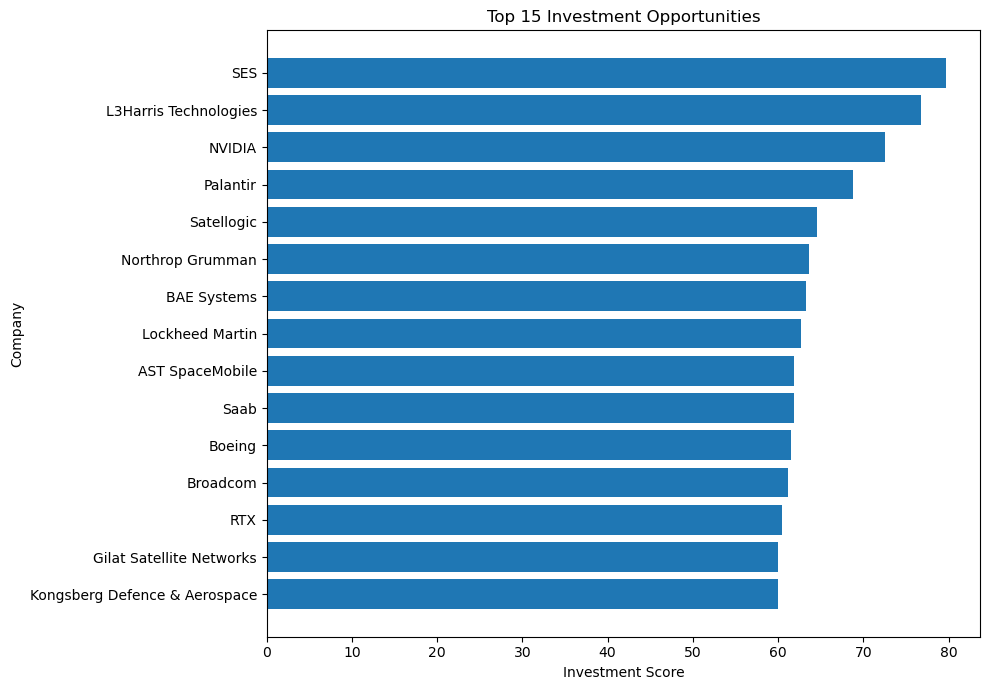

In [66]:
top_15 = (
    investment_ranking
    .head(15)
    .sort_values("Investment Score", ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_15["Company"],
    top_15["Investment Score"]
)

plt.xlabel("Investment Score")
plt.ylabel("Company")
plt.title("Top 15 Investment Opportunities")

plt.tight_layout()
plt.show()

## 2. Sector Distribution

This chart shows the number of companies represented in each major sector of the dataset.

It provides context for interpreting the investment ranking and highlights the breadth of the global space-economy value chain.

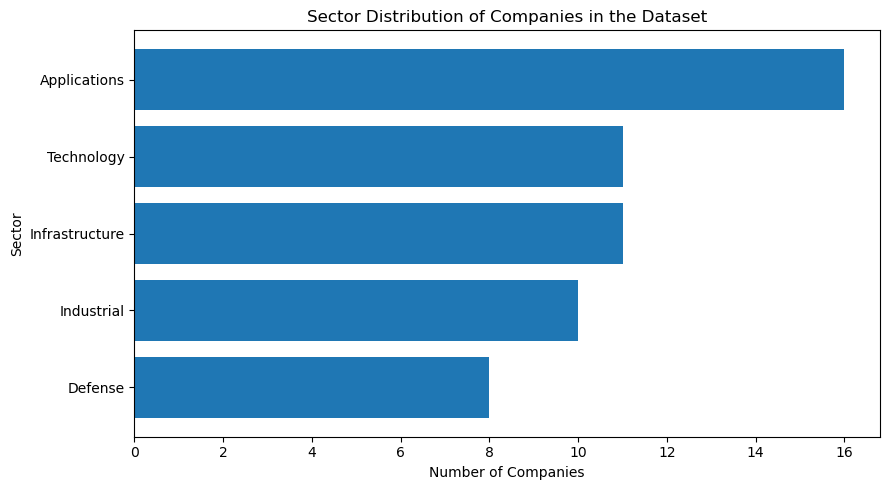

In [63]:
sector_counts = (
    df["Sector"]
    .value_counts()
    .sort_values(ascending=True)
)

plt.figure(figsize=(9, 5))

plt.barh(
    sector_counts.index,
    sector_counts.values
)

plt.xlabel("Number of Companies")
plt.ylabel("Sector")
plt.title("Sector Distribution of Companies in the Dataset")

plt.tight_layout()
plt.show()

## 3. Revenue Growth and Profitability

This scatter plot compares winsorised revenue growth with profit margin across companies in the dataset.

Winsorisation is applied to revenue growth to reduce the influence of extreme outliers while preserving the overall distribution.

Each point represents one company:

- The horizontal axis shows winsorised revenue growth.
- The vertical axis shows profit margin.
- Point size represents company revenue (log-scaled).
- Point colour represents the Space Economy Exposure Score.

This visualisation highlights companies that combine sustainable growth, strong profitability, commercial scale and meaningful exposure to the space economy.

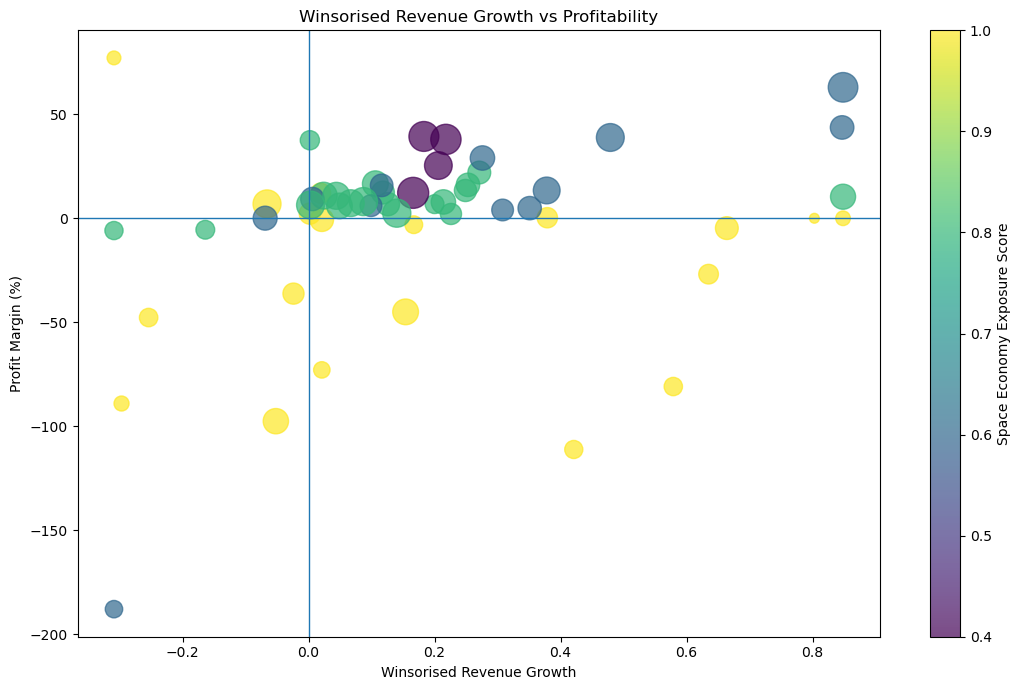

In [67]:
plot_df = df[
    [
        "Company",
        "Revenue Growth Adjusted",
        "Profit Margin",
        "Revenue USD",
        "Space Economy Exposure Score"
    ]
].dropna().copy()

log_revenue = np.log1p(plot_df["Revenue USD"])

bubble_size = (
    50
    + 450
    * (
        (log_revenue - log_revenue.min())
        /
        (log_revenue.max() - log_revenue.min())
    )
)

plt.figure(figsize=(11, 7))

scatter = plt.scatter(
    plot_df["Revenue Growth Adjusted"],
    plot_df["Profit Margin"] * 100,
    s=bubble_size,
    c=plot_df["Space Economy Exposure Score"],
    alpha=0.7
)

plt.xlabel("Winsorised Revenue Growth")
plt.ylabel("Profit Margin (%)")
plt.title("Winsorised Revenue Growth vs Profitability")

plt.colorbar(
    scatter,
    label="Space Economy Exposure Score"
)

plt.axhline(0, linewidth=1)
plt.axvline(0, linewidth=1)

plt.tight_layout()
plt.show()

# Conclusions

This project developed a transparent multi-factor investment framework for evaluating publicly listed companies across the global space economy.

Unlike approaches that rely on a single financial metric, the proposed framework combines six complementary factors:

- Space Economy Exposure
- Company Size (Revenue)
- Revenue Growth
- Profitability
- Valuation
- Market Risk

To ensure comparability, each factor is normalized to a common 0–1 scale before being combined into a weighted Investment Score.

The results demonstrate that investment attractiveness cannot be explained by a single indicator alone. Instead, companies that consistently perform well across multiple dimensions—including industry exposure, financial strength, sustainable growth, attractive valuation and lower market risk—achieve the highest overall Investment Scores.

Although the scoring framework is intentionally simple, it provides a transparent and reproducible methodology for comparing companies across different sectors of the global space economy. Rather than predicting future stock prices, the framework offers a systematic way to screen investment opportunities using publicly available financial data.

Future work could extend the model by incorporating additional financial indicators such as free cash flow, debt ratios, earnings quality and historical volatility. More sophisticated weighting methods or machine learning techniques could also be explored to further improve the robustness of the investment ranking.